In [21]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [22]:
import re,sys,os
import pandas as pd
import numpy as np
from tqdm import tqdm
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib

# Set font to Arial
matplotlib.rcParams['font.family'] = 'Arial'

# Optional: Set PDF to embed fonts (for Illustrator editing)
matplotlib.rcParams['pdf.fonttype'] = 42  # TrueType fonts for better editing

In [27]:
DATA_DIR = Path(r"D:\lab\cptac_prostate\data\v4\CPTAC")
OUTPUT_DIR = Path(r"D:\lab\cptac_prostate\runs\20260330_cptac_protein_tmt_diff")
print(DATA_DIR.exists(), OUTPUT_DIR.exists())
meta_path = DATA_DIR / "20_MetaData_03_12_2026.csv"

True True


In [28]:
meta = pd.read_csv(meta_path)
meta

,case_id,common_ID,Tissuetype,include_or_excludetumor,FirstCategory,AdditionalSegments,SecondCategory,ThirdCategory,all_drivers,Main_Groups,...,LumB_Pam50,Normal_Pam50,Basal,Her2,LumA,LumB,Normal,agg_rank_raw,agg_rank_scaled,risk_group
0,C3L-07287,C3L.07287.T,tumor,Include,Sufficient Purity,ETS,ETS,NaN,ERG,ERG,...,0.342000,0.000000,0.0,0.0,1.0,0.0,0.0,55.333000,0.409000,IR
1,C3L-11156,C3L.11156.T,tumor,Include,Sufficient Purity,ETS,ETS,NaN,ERG,ERG,...,0.000000,0.498000,0.0,0.0,1.0,0.0,0.0,44.167000,0.325000,LR
2,C3L-09494,C3L.09494.T,tumor,Include,Sufficient Purity,ETS,ETS,NaN,ERG,ERG,...,0.281000,0.000000,0.0,1.0,0.0,0.0,0.0,123.167000,0.919000,HR
3,CHTN-49141,CHTN.49141.T,tumor,Include,Sufficient Purity,ETS,ETS,NaN,ERG,ERG,...,0.420000,0.000000,0.0,1.0,0.0,0.0,0.0,103.833000,0.773000,HR
4,C3L-11095,C3L.11095.T,tumor,Include,Sufficient Purity,ETS,ETS,NaN,ERG,ERG,...,0.000000,0.369000,0.0,0.0,1.0,0.0,0.0,44.667000,0.328000,LR
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
178,C3L-07872,C3L.07872.T,tumor,Include,Low Purity,NaN,NaN,NaN,ERG,ERG,...,0.000000,0.460832,1.0,0.0,0.0,0.0,0.0,73.666667,0.546366,IR
179,C3L-08642,C3L.08642.T,tumor,Include,Low Purity,NaN,NaN,NaN,ERG,ERG,...,0.000000,0.334840,0.0,0.0,1.0,0.0,0.0,46.166667,0.339599,LR
180,C3L-10399,C3L.10399.T,tumor,Include,Low Purity,NaN,NaN,NaN,ERG,ERG,...,0.000000,0.445334,0.0,0.0,1.0,0.0,0.0,60.000000,0.443609,IR
181,C3L-05301,C3L.05301.T,tumor,Include,Low Purity,NaN,NaN,NaN,ETV1,ETV1,...,0.000000,0.457908,0.0,0.0,1.0,0.0,0.0,45.333333,0.333333,LR


In [35]:
meta_include = meta[meta["include_or_excludetumor"] == "Include"]
meta_include

,case_id,common_ID,Tissuetype,include_or_excludetumor,FirstCategory,AdditionalSegments,SecondCategory,ThirdCategory,all_drivers,Main_Groups,...,LumB_Pam50,Normal_Pam50,Basal,Her2,LumA,LumB,Normal,agg_rank_raw,agg_rank_scaled,risk_group
0,C3L-07287,C3L.07287.T,tumor,Include,Sufficient Purity,ETS,ETS,NaN,ERG,ERG,...,0.342000,0.000000,0.0,0.0,1.0,0.0,0.0,55.333000,0.409000,IR
1,C3L-11156,C3L.11156.T,tumor,Include,Sufficient Purity,ETS,ETS,NaN,ERG,ERG,...,0.000000,0.498000,0.0,0.0,1.0,0.0,0.0,44.167000,0.325000,LR
2,C3L-09494,C3L.09494.T,tumor,Include,Sufficient Purity,ETS,ETS,NaN,ERG,ERG,...,0.281000,0.000000,0.0,1.0,0.0,0.0,0.0,123.167000,0.919000,HR
3,CHTN-49141,CHTN.49141.T,tumor,Include,Sufficient Purity,ETS,ETS,NaN,ERG,ERG,...,0.420000,0.000000,0.0,1.0,0.0,0.0,0.0,103.833000,0.773000,HR
4,C3L-11095,C3L.11095.T,tumor,Include,Sufficient Purity,ETS,ETS,NaN,ERG,ERG,...,0.000000,0.369000,0.0,0.0,1.0,0.0,0.0,44.667000,0.328000,LR
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
178,C3L-07872,C3L.07872.T,tumor,Include,Low Purity,NaN,NaN,NaN,ERG,ERG,...,0.000000,0.460832,1.0,0.0,0.0,0.0,0.0,73.666667,0.546366,IR
179,C3L-08642,C3L.08642.T,tumor,Include,Low Purity,NaN,NaN,NaN,ERG,ERG,...,0.000000,0.334840,0.0,0.0,1.0,0.0,0.0,46.166667,0.339599,LR
180,C3L-10399,C3L.10399.T,tumor,Include,Low Purity,NaN,NaN,NaN,ERG,ERG,...,0.000000,0.445334,0.0,0.0,1.0,0.0,0.0,60.000000,0.443609,IR
181,C3L-05301,C3L.05301.T,tumor,Include,Low Purity,NaN,NaN,NaN,ETV1,ETV1,...,0.000000,0.457908,0.0,0.0,1.0,0.0,0.0,45.333333,0.333333,LR


In [37]:
meta_exclude = meta[meta["include_or_excludetumor"] == "exclude"]
meta_exclude

,case_id,common_ID,Tissuetype,include_or_excludetumor,FirstCategory,AdditionalSegments,SecondCategory,ThirdCategory,all_drivers,Main_Groups,...,LumB_Pam50,Normal_Pam50,Basal,Her2,LumA,LumB,Normal,agg_rank_raw,agg_rank_scaled,risk_group
144,C3L-09492,C3L.09492.T,tumor,exclude,No Tumor,NaN,NaN,NaN,NaN,No Tumor,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
145,C3L-09497,C3L.09497.T,tumor,exclude,No Tumor,NaN,NaN,NaN,NaN,No Tumor,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
146,C3L-06260,C3L.06260.T,tumor,exclude,No Tumor,NaN,NaN,NaN,NaN,No Tumor,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
147,C3L-06510,C3L.06510.T,tumor,exclude,No Tumor,NaN,NaN,NaN,NaN,No Tumor,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
148,C3L-07890,C3L.07890.T,tumor,exclude,No Tumor,NaN,NaN,NaN,NaN,No Tumor,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
149,C3L-09372,C3L.09372.T,tumor,exclude,No Tumor,NaN,NaN,NaN,NaN,No Tumor,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
150,C3N-09047,C3N.09047.T,tumor,exclude,No Tumor,NaN,NaN,NaN,NaN,No Tumor,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
151,C3L-07868,C3L.07868.T,tumor,exclude,No Tumor,NaN,NaN,NaN,NaN,No Tumor,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
152,C3L-09563,C3L.09563.T,tumor,exclude,No Tumor,NaN,NaN,NaN,NaN,No Tumor,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
153,C3L-10319,C3L.10319.T,tumor,exclude,No Tumor,NaN,NaN,NaN,NaN,No Tumor,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [40]:
meta_normal = meta[meta["include_or_excludetumor"] == "normal"]
meta_normal

,case_id,common_ID,Tissuetype,include_or_excludetumor,FirstCategory,AdditionalSegments,SecondCategory,ThirdCategory,all_drivers,Main_Groups,...,LumB_Pam50,Normal_Pam50,Basal,Her2,LumA,LumB,Normal,agg_rank_raw,agg_rank_scaled,risk_group
111,C3L-07813,C3L.07813.N,normal,normal,Normal,NaN,NaN,NaN,normal,normal,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
112,C3L-06504,C3L.06504.N,normal,normal,Normal,NaN,NaN,NaN,normal,normal,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
113,C3L-06506,C3L.06506.N,normal,normal,Normal,NaN,NaN,NaN,normal,normal,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
114,C3L-06741,C3L.06741.N,normal,normal,Normal,NaN,NaN,NaN,normal,normal,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
115,C3L-06890,C3L.06890.N,normal,normal,Normal,NaN,NaN,NaN,normal,normal,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
116,C3L-06901,C3L.06901.N,normal,normal,Normal,NaN,NaN,NaN,normal,normal,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
117,C3L-06743,C3L.06743.N,normal,normal,Normal,NaN,NaN,NaN,normal,normal,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
118,C3L-07607,C3L.07607.N,normal,normal,Normal,NaN,NaN,NaN,normal,normal,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
119,C3L-06436,C3L.06436.N,normal,normal,Normal,NaN,NaN,NaN,normal,normal,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
120,C3L-07809,C3L.07809.N,normal,normal,Normal,NaN,NaN,NaN,normal,normal,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [39]:
tumors_included = meta_include['common_ID'].tolist()
tumors_excluded = meta_exclude['common_ID'].tolist()
print(len(tumors_included), len(tumors_excluded))

134 16


In [41]:
normals = meta_normal['common_ID'].tolist()
print(len(normals))

33


In [31]:
# data
files = [i for i in DATA_DIR.iterdir() if i.is_file()]
files = [i for i in files if re.search(r"prot_TMT_abundance_gene_MD",i.stem, re.IGNORECASE) and not re.search(r"tumor_purity_corrected",i.stem, re.IGNORECASE)]
data_path = files[0]
protein_header_cols = ["geneSymbol","Index"]
data = pd.read_csv(data_path,sep="\t").set_index(protein_header_cols)
data_nomiss = data.dropna()

In [32]:
data

,,C3L.05292.T,C3L.09383.T,CHTN.43798.T,C3L.06261.N,C3L.08811.T,C3L.06506.N,C3L.07804.T,C3L.06595.T,C3L.06742.T,CHTN.45205.T,...,C3L.07875.T,CHTN.44966.T,C3L.11192.N,C3L.08805.T,C3L.09760.T,C3L.08444.T,C3L.08291.T,C3L.10583.T,C3L.07877.T,C3L.08736.T
geneSymbol,Index,,,,,,,,,,,,,,,,,,,,,
TSPAN6,ENSG00000000003,26.241703,25.762754,26.032218,26.381072,27.225921,25.422672,26.056571,25.685108,25.409483,25.832296,...,25.870356,25.550479,24.613594,25.356010,26.120281,26.726276,26.219614,26.604706,24.532449,26.166802
DPM1,ENSG00000000419,26.735998,26.655233,26.802290,26.773513,26.568686,26.665666,26.847345,26.661661,26.815732,26.833067,...,26.749665,26.608061,26.600346,26.230216,26.698289,26.668585,26.855219,26.558799,26.924456,27.419519
SCYL3,ENSG00000000457,23.310843,23.545564,23.445102,23.227654,23.477484,23.490504,23.337468,23.530186,23.332166,23.205060,...,23.221220,23.474428,23.435554,23.000802,23.245226,23.580775,23.200994,23.195602,23.320165,23.322957
C1orf112,ENSG00000000460,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CFH,ENSG00000000971,25.756338,27.153898,26.142468,27.755129,27.206709,27.182646,27.331458,26.904309,27.482806,26.595564,...,27.484376,26.805169,26.671614,27.141799,26.720132,26.756454,26.608394,27.907630,27.452700,26.292539
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000289694,ENSG00000289694,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ENSG00000289697,ENSG00000289697,28.119673,28.892325,28.840137,29.335765,28.730543,29.423759,28.978452,29.023038,28.986803,28.756232,...,28.765767,29.059414,28.823691,29.260718,28.683234,28.367403,28.553459,29.613925,28.854303,28.268796
HOMEZ,ENSG00000290292,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [33]:
data_nomiss

,,C3L.05292.T,C3L.09383.T,CHTN.43798.T,C3L.06261.N,C3L.08811.T,C3L.06506.N,C3L.07804.T,C3L.06595.T,C3L.06742.T,CHTN.45205.T,...,C3L.07875.T,CHTN.44966.T,C3L.11192.N,C3L.08805.T,C3L.09760.T,C3L.08444.T,C3L.08291.T,C3L.10583.T,C3L.07877.T,C3L.08736.T
geneSymbol,Index,,,,,,,,,,,,,,,,,,,,,
TSPAN6,ENSG00000000003,26.241703,25.762754,26.032218,26.381072,27.225921,25.422672,26.056571,25.685108,25.409483,25.832296,...,25.870356,25.550479,24.613594,25.356010,26.120281,26.726276,26.219614,26.604706,24.532449,26.166802
DPM1,ENSG00000000419,26.735998,26.655233,26.802290,26.773513,26.568686,26.665666,26.847345,26.661661,26.815732,26.833067,...,26.749665,26.608061,26.600346,26.230216,26.698289,26.668585,26.855219,26.558799,26.924456,27.419519
SCYL3,ENSG00000000457,23.310843,23.545564,23.445102,23.227654,23.477484,23.490504,23.337468,23.530186,23.332166,23.205060,...,23.221220,23.474428,23.435554,23.000802,23.245226,23.580775,23.200994,23.195602,23.320165,23.322957
CFH,ENSG00000000971,25.756338,27.153898,26.142468,27.755129,27.206709,27.182646,27.331458,26.904309,27.482806,26.595564,...,27.484376,26.805169,26.671614,27.141799,26.720132,26.756454,26.608394,27.907630,27.452700,26.292539
FUCA2,ENSG00000001036,26.392032,26.466556,26.395183,25.611974,26.431247,25.498467,25.388730,26.004691,26.703585,26.425195,...,26.413351,26.107662,25.802904,26.003041,26.390879,25.976823,26.899157,25.631412,25.940254,27.157712
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000288796,ENSG00000288796,24.121256,25.607403,23.958328,24.658986,24.550683,25.837965,23.831235,25.423006,23.841341,24.981982,...,24.778188,24.508386,25.002398,24.436574,24.186467,24.985155,24.501564,26.442352,24.345976,23.889129
ENSG00000289027,ENSG00000289027,23.785389,23.592146,24.244645,23.715723,23.626125,24.153922,24.081663,23.896070,23.400703,23.728672,...,23.789613,23.534495,23.656807,23.887515,23.841740,24.168523,23.957458,23.569846,23.952552,23.863057
ENSG00000289697,ENSG00000289697,28.119673,28.892325,28.840137,29.335765,28.730543,29.423759,28.978452,29.023038,28.986803,28.756232,...,28.765767,29.059414,28.823691,29.260718,28.683234,28.367403,28.553459,29.613925,28.854303,28.268796


In [34]:
samples = data.columns.tolist()
len(samples)

178

In [42]:
set_tumors_included = set(tumors_included)
set_tumors_excluded = set(tumors_excluded)
set_normals = set(normals)
set_data = set(samples)
print((len(set_tumors_included), len(set_tumors_excluded), len(set_normals), len(set_data)))

(134, 16, 33, 178)


In [44]:
set_data - set_tumors_included - set_tumors_excluded - set_normals

{'C3L.06436.T',
 'C3L.07292.N',
 'C3L.07606.N',
 'C3L.08546.T',
 'C3L.09345.T',
 'C3L.09373.T',
 'C3L.09793.T',
 'C3L.09832.T',
 'C3L.09972.T',
 'C3L.10301.T',
 'CHTN.47295.T'}

<Figure size 800x800 with 0 Axes>

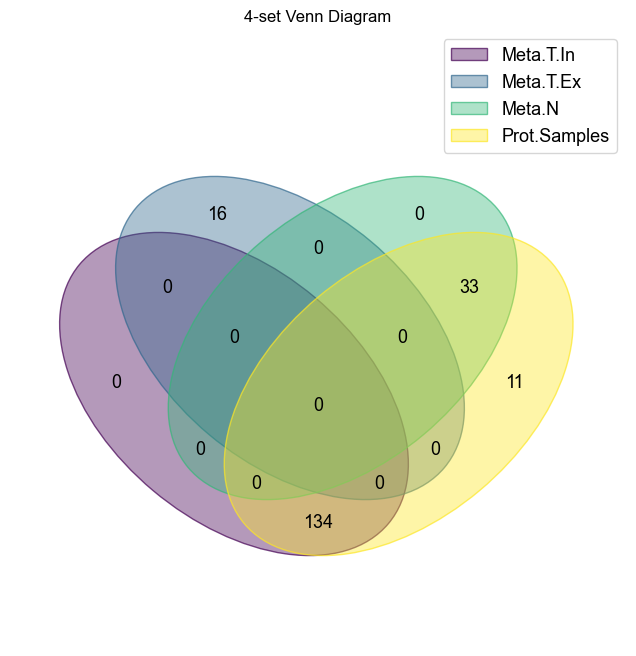

In [43]:
import matplotlib.pyplot as plt
from venn import venn

# 四个集合
sets = {
    "Meta.T.In": set_tumors_included,
    "Meta.T.Ex": set_tumors_excluded,
    "Meta.N": set_normals,
    "Prot.Samples": set_data
}

plt.figure(figsize=(8, 8))
venn(sets)
plt.title("4-set Venn Diagram")
plt.show()